In [1]:
# Project 2 - Data Classification Using AI

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris

print("Libraries imported successfully!")


Libraries imported successfully!


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris

print("Libraries imported successfully!")

Libraries imported successfully!


In [3]:
# Load Iris dataset
iris = load_iris()

print("Dataset loaded successfully!")
print("Features:", iris.feature_names)
print("Target names:", iris.target_names)
print("Shape:", iris.data.shape)


Dataset loaded successfully!
Features: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Target names: ['setosa' 'versicolor' 'virginica']
Shape: (150, 4)


In [4]:
# Convert Iris dataset into a DataFrame

df = pd.DataFrame(
    iris.data,
    columns=iris.feature_names
)

# Add target column
df['target'] = iris.target

print(df.head())

   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   target  
0       0  
1       0  
2       0  
3       0  
4       0  


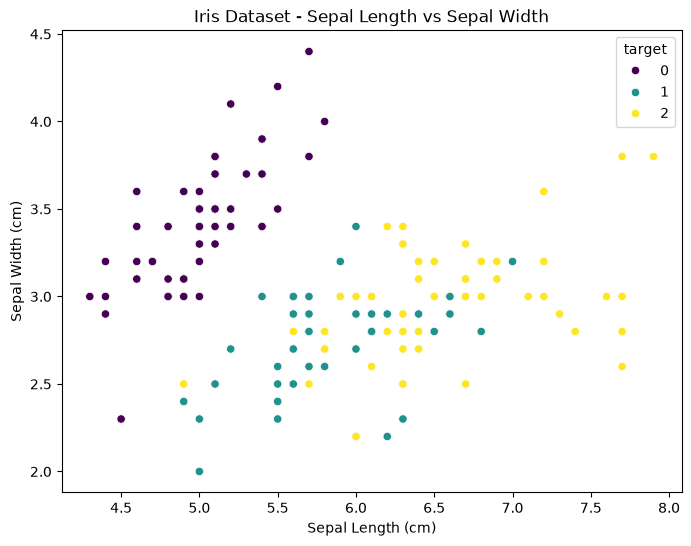

In [5]:
# Visualize the Iris dataset

plt.figure(figsize=(8, 6))

sns.scatterplot(
    x='sepal length (cm)',
    y='sepal width (cm)',
    hue='target',
    data=df,
    palette='viridis'
)

plt.title('Iris Dataset - Sepal Length vs Sepal Width')
plt.xlabel('Sepal Length (cm)')
plt.ylabel('Sepal Width (cm)')
plt.show()


In [6]:
# Separate features (X) and target (y)

X = df.drop('target', axis=1)
y = df['target']

print("Features (X):")
print(X.head())

print("\nTarget (y):")
print(y.head())

Features (X):
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0                5.1               3.5                1.4               0.2
1                4.9               3.0                1.4               0.2
2                4.7               3.2                1.3               0.2
3                4.6               3.1                1.5               0.2
4                5.0               3.6                1.4               0.2

Target (y):
0    0
1    0
2    0
3    0
4    0
Name: target, dtype: int64


In [7]:
from sklearn.model_selection import train_test_split

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (120, 4)
Testing data: (30, 4)


In [8]:
from sklearn.tree import DecisionTreeClassifier

# Create the Decision Tree model
model = DecisionTreeClassifier(random_state=42)

# Train the model
model.fit(X_train, y_train)

print("Decision Tree model trained successfully!")

Decision Tree model trained successfully!


In [9]:
from sklearn.metrics import accuracy_score

# Make predictions on test data
y_pred = model.predict(X_test)

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)

print("Predictions:", y_pred)
print("Actual values:", y_test.values)
print("Accuracy:", accuracy)
print("Accuracy Percentage:", accuracy * 100, "%")

Predictions: [1 0 2 1 1 0 1 2 1 1 2 0 0 0 0 1 2 1 1 2 0 2 0 2 2 2 2 2 0 0]
Actual values: [1 0 2 1 1 0 1 2 1 1 2 0 0 0 0 1 2 1 1 2 0 2 0 2 2 2 2 2 0 0]
Accuracy: 1.0
Accuracy Percentage: 100.0 %


Confusion Matrix:
[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]


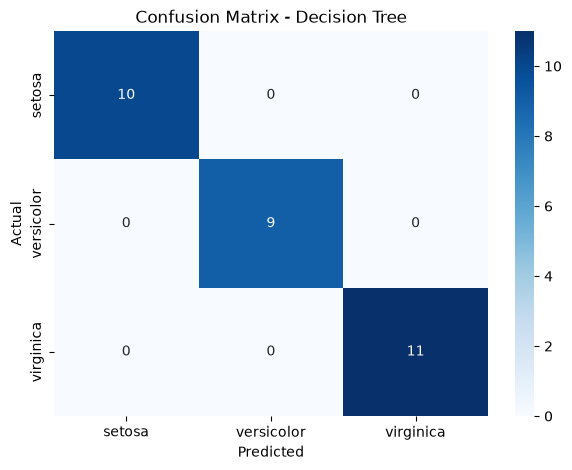

In [10]:
from sklearn.metrics import confusion_matrix

# Create confusion matrix
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

# Visualize confusion matrix
plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=iris.target_names,
    yticklabels=iris.target_names
)

plt.title('Confusion Matrix - Decision Tree')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

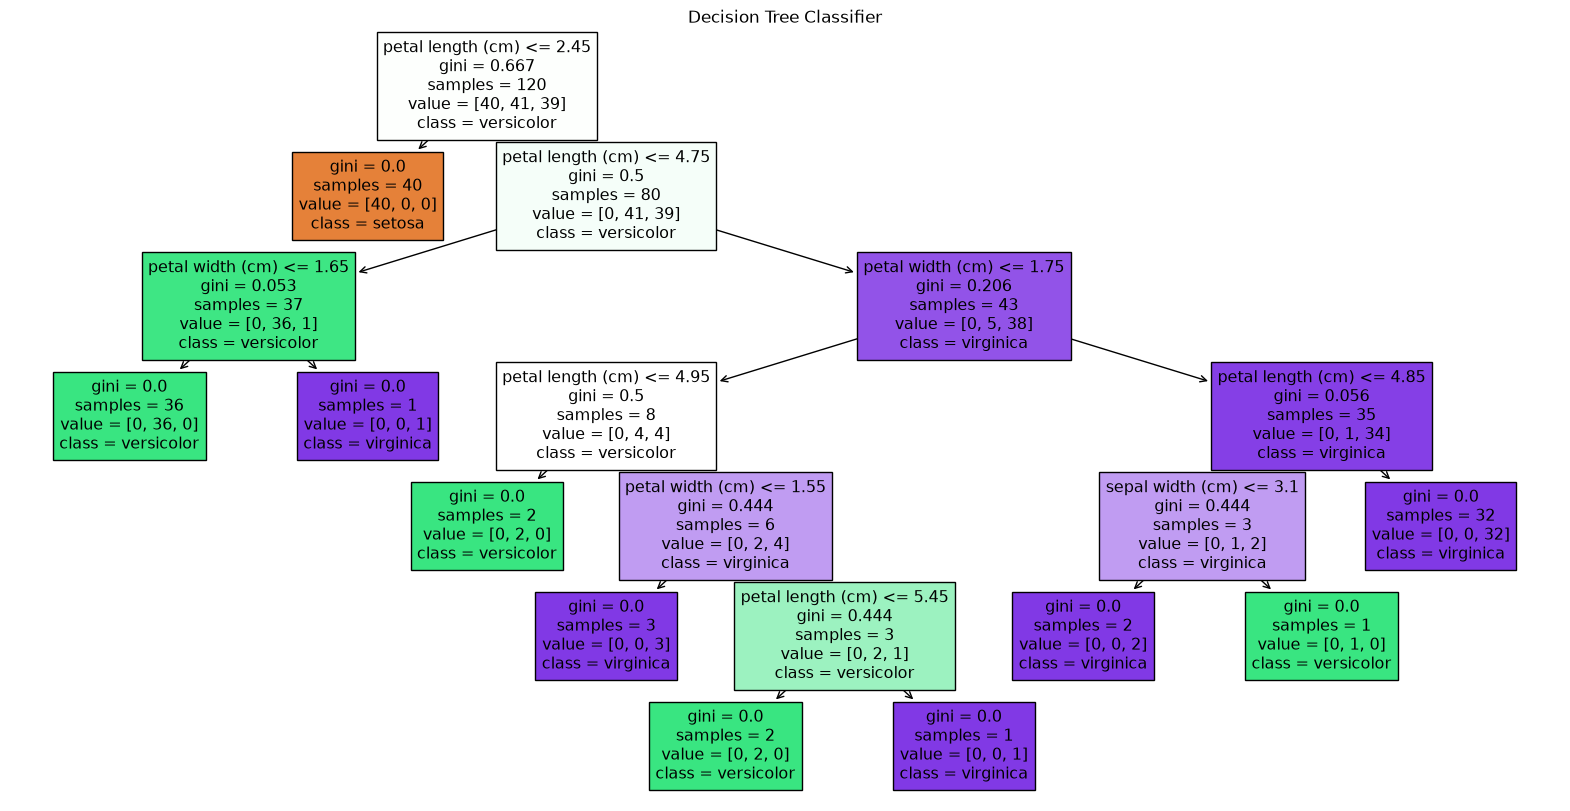

In [11]:
from sklearn.tree import plot_tree

plt.figure(figsize=(20, 10))

plot_tree(
    model,
    feature_names=iris.feature_names,
    class_names=iris.target_names,
    filled=True
)

plt.title("Decision Tree Classifier")
plt.show()

In [12]:
from sklearn.ensemble import RandomForestClassifier

# Create Random Forest model
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

# Train the model
rf_model.fit(X_train, y_train)

print("Random Forest model trained successfully!")

Random Forest model trained successfully!


In [13]:
from sklearn.metrics import accuracy_score

# Make predictions using Random Forest
rf_pred = rf_model.predict(X_test)

# Calculate accuracy
rf_accuracy = accuracy_score(y_test, rf_pred)

print("Random Forest Predictions:", rf_pred)
print("Actual values:", y_test.values)
print("Random Forest Accuracy:", rf_accuracy)
print("Random Forest Accuracy Percentage:", rf_accuracy * 100, "%")

Random Forest Predictions: [1 0 2 1 1 0 1 2 1 1 2 0 0 0 0 1 2 1 1 2 0 2 0 2 2 2 2 2 0 0]
Actual values: [1 0 2 1 1 0 1 2 1 1 2 0 0 0 0 1 2 1 1 2 0 2 0 2 2 2 2 2 0 0]
Random Forest Accuracy: 1.0
Random Forest Accuracy Percentage: 100.0 %


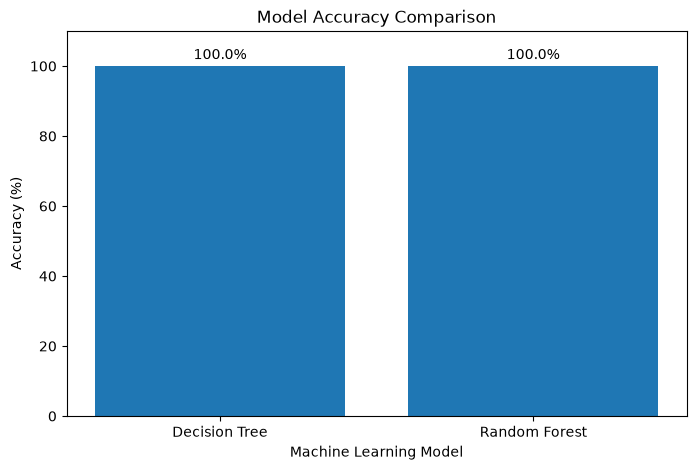

In [14]:
# Compare model accuracies

models = ['Decision Tree', 'Random Forest']
accuracies = [accuracy * 100, rf_accuracy * 100]

plt.figure(figsize=(8, 5))

plt.bar(models, accuracies)

plt.title('Model Accuracy Comparison')
plt.xlabel('Machine Learning Model')
plt.ylabel('Accuracy (%)')
plt.ylim(0, 110)

for i, value in enumerate(accuracies):
    plt.text(i, value + 2, f'{value:.1f}%', ha='center')

plt.show()

## Conclusion

In this project, the Iris dataset was used to build a supervised machine learning classification model. The dataset was divided into training and testing sets using an 80/20 split.

A Decision Tree Classifier was trained and evaluated using test data. The model achieved 100% accuracy on the test dataset. A Random Forest Classifier was also trained for comparison and achieved 100% accuracy.

The project demonstrated the basic AI classification pipeline, including data loading, data preprocessing, train-test splitting, model training, prediction, evaluation, and visualization.